<a href="https://colab.research.google.com/github/CodeChef-1/Comp-215/blob/main/Kelvin's_Tidal_force_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello im Kelvin Tse, This is my project and documentation on my tidal forces project.

The main source I used was the linked research paper in the next text block, however I also used AI assistance to debug my code and write the good looking print statements, The objects and forumlas are written by me.

Some parts where I needed AI to help me:


*   Fixing some formatting in my graph to make it look better

*   finding the optimal 10 points to graph
*   Creating better looking print statements




Step 1: Research and planning



*   Why am I doing this project: Tidal forces always intreseted me since we on earth can see the direct effects of tidal forces on our planet and ocean
*   Where are my sources: I did quite a bit of research however this: https://www.uaf.edu/cfos/files/research-projects/people/kowalik/Book2019_tides.pdf [paper] written by university of Alaska professors was more than enought to teach me everything I learned for this project. (using mostly chapters 1, 2).


*   Why are tidal forces caused: Gravity, the moon pulls water up slightly on the face of the earth that is between the moon and earth. The other side of the earth has the same effect due to the differance of force between the two "High tide humps" on the planet


Step 2: creating the function
Steps to creating the "tidal force calculator"

1.   Create an object for each planet, (going to start with just the earth and moon)
2.   create a object functions for forces
3.   test if it can compute forces correctly
4.   add the sun to check for change in forces
5.   run the function at different distances and graph data



Step 3: writing findings bettween iterations of my function these updates can be found under each printout of the functions.



**Notes after finishing my project:**

I took a little longer than I expected since I was getting a little to ambious trying to calculate the average height of tides.
Instead I settles on a simpler model which simply graphs the tidal acceleration on earth from the sun and moon.
The part I had some trouble with was figuring out which 10 best points to use for the graph, I had some AI assist me with figuring that out which you can see the formula for later in the 3rd function.

# **A Guide to reading and using this notebook:**
(Click connect to runtime in the top right of the screen to get started, run the functions in order of 1st to 3rd for proper function)


my observations and thought process are in text blocks between the code blocks. Along with that some explainations of certain varibles and functions are also included as "#" or hashtaged comments above or around the function/varible
This program runs on google servers so it should not require you to be on a good computer to run. My last runtime will show up if you click the small "show hidden output" button on the end of each code block. The final printout under code block 3 has a data table and a graph that was made using MatPlotLib (common graphing library)

Formulas -> functions

F=G(m1m2/r^2)

    F: Gravitational force (Newtons, N)

    G: Universal Gravitational Constant (G≈6.674×10−11kg2N⋅m2​)

    m1​,m2​: Masses of the two objects (kilograms, kg)

    r: Distance between the centers of the two masses (meters, m)

Dirived formula from paper, Tidal acceleration = 2G(M1Re/r^3)

    M1: Mass of other body (the one that isnt earth) (in Kg)

    G: Universal Gravitational Constant (G≈6.674×10−11kg2N⋅m2​)

    r: Distance between the centers of the two masses (meters, m)



In [ ]:
import numpy as np

G = 6.674e-11  # G constant to use later

# Making class "planet" to create my later planets for testing (I know the sun is not a planet, just using the term planet instead of celestial body so I can type less)
class Planet:

    def __init__(self, name, mass_kg, radius_m):
      #defining the variables for the planets
        self.name = name
        self.mass = mass_kg
        self.radius = radius_m

    def calculate_gravitational_force(self, body_c, distance_m):
        #calculates FG using mass and distance for given planet
        force_g = G * self.mass * body_c.mass / (distance_m**2)

        #Prints values with nice formatting
        print(f"  -> Gravitational Force (F_G) with {body_c.name}:")
        print(f"     Machine Code/Calculation Output (N): {force_g}")
        print(f"     Human Readable Output (N): {force_g:.4e}")
        return force_g

    def calculate_tidal_acceleration(self, body_c, distance_m):
        tidal_accel = 2 * G * body_c.mass * self.radius / (distance_m**3)
        #Prints in same format as the other but displays the tidal acceleration
        print(f"  -> Tidal Acceleration (a_tidal) due to {body_c.name}:")
        print(f"     Machine Code/Calculation Output (m/s^2): {tidal_accel}")
        print(f"     Human Readable Output (m/s^2): {tidal_accel:.4e}")
        return tidal_accel

#Earth constants
earth_mass = 5.972e24
earth_radius = 6.371e6
earth = Planet("Earth", earth_mass, earth_radius)

#Moon constants
moon_mass = 7.347e22
moon_radius = 1.7374e6
moon = Planet("Moon", moon_mass, moon_radius)

#Sun constants
sun_mass = 1.989e30
sun_radius = 6.963e8
sun = Planet("Sun", sun_mass, sun_radius)

#Rounded distance constants (in meters)
earth_moon_distance = 3.844e8
earth_sun_distance = 1.496e11

#Result calculations
print("===============================================")
print("### Tidal Force Project: Earth, Moon, and Sun ###")
print("===============================================")

#For Moon--Earth
print("\n[A] MOON'S INFLUENCE ON EARTH:")
print("------------------------------")
#FG calc
force_moon = earth.calculate_gravitational_force(
    body_c=moon,
    distance_m=earth_moon_distance
)

#The differances between the sides
accel_moon = earth.calculate_tidal_acceleration(
    body_c=moon,
    distance_m=earth_moon_distance
)

#For Sun--Earth
print("\n[B] SUN'S INFLUENCE ON EARTH:")
print("-----------------------------")
#FG calc again
force_sun = earth.calculate_gravitational_force(
    body_c=sun,
    distance_m=earth_sun_distance
)

#Tidal acceleration calc
accel_sun = earth.calculate_tidal_acceleration(
    body_c=sun,
    distance_m=earth_sun_distance
)

#Comparison
print("\n[C] SUMMARY AND COMPARISON:")
print("---------------------------")
print(f"**1. Gravitational Force (F_G):**")
print(f"   Sun's F_G on Earth: {force_sun:.4e} N")
print(f"   Moon's F_G on Earth: {force_moon:.4e} N")
ratio_force = force_sun / force_moon
print(f"   (The Sun pulls on Earth about {ratio_force:.1f} times harder than the Moon.)")

print(f"\n**2. Tidal Acceleration (a_tidal):**")
print(f"   Moon's a_tidal on Earth: {accel_moon:.4e} m/s^2")
print(f"   Sun's a_tidal on Earth: {accel_sun:.4e} m/s^2")
ratio_tidal = accel_moon / accel_sun
print(f"   (The Moon's tidal effect is about {ratio_tidal:.1f} times stronger than the Sun's.)")

### Tidal Force Project: Earth, Moon, and Sun ###

[A] MOON'S INFLUENCE ON EARTH:
------------------------------
  -> Gravitational Force (F_G) with Moon:
     Machine Code/Calculation Output (N): 1.9817518999026552e+20
     Human Readable Output (N): 1.9818e+20
  -> Tidal Acceleration (a_tidal) due to Moon:
     Machine Code/Calculation Output (m/s^2): 1.0999772572281306e-06
     Human Readable Output (m/s^2): 1.1000e-06

[B] SUN'S INFLUENCE ON EARTH:
-----------------------------
  -> Gravitational Force (F_G) with Sun:
     Machine Code/Calculation Output (N): 3.542236855858046e+22
     Human Readable Output (N): 3.5422e+22
  -> Tidal Acceleration (a_tidal) due to Sun:
     Machine Code/Calculation Output (m/s^2): 5.052005394307035e-07
     Human Readable Output (m/s^2): 5.0520e-07

[C] SUMMARY AND COMPARISON:
---------------------------
**1. Gravitational Force (F_G):**
   Sun's F_G on Earth: 3.5422e+22 N
   Moon's F_G on Earth: 1.9818e+20 N
   (The Sun pulls on Earth about 178.7 t

For all future functions I write (stuff past this point) I will remove the documentation for the Class and objects it instantiates since the documentation is the same.

The first itteration of the function, It calculated the tidal force and acceleration using formulas I borrowed from the research paper. Carrying that forward add another object function to calculate the differances between "Neap" and "spring" tides (Low and High). This is done by adding the forces of the sun and moon (aligned for spring tide) together to get the total tidal acceleration and the opposite (subtracting sun from moon) for neap tides when the mooon is perpendicular to the sun at a quarter. The reason for adding and subtracting the forces are due to the perendicular vectors explained in the paper.

In [ ]:
import numpy as np

G = 6.674e-11

class Planet:

    def __init__(self, name, mass_kg, radius_m):
        self.name = name
        self.mass = mass_kg
        self.radius = radius_m

    def calculate_gravitational_force(self, body_c, distance_m):
        force_g = G * self.mass * body_c.mass / (distance_m**2)
        return force_g

    def calculate_tidal_acceleration(self, body_c, distance_m):
        tidal_accel = 2 * G * body_c.mass * self.radius / (distance_m**3)
        return tidal_accel

earth_mass = 5.972e24
earth_radius = 6.371e6
earth = Planet("Earth", earth_mass, earth_radius)

moon_mass = 7.347e22
moon = Planet("Moon", moon_mass, 1.7374e6)

sun_mass = 1.989e30
sun = Planet("Sun", sun_mass, 6.963e8)

earth_moon_distance = 3.844e8
earth_sun_distance = 1.496e11

accel_moon = earth.calculate_tidal_acceleration(
    body_c=moon,
    distance_m=earth_moon_distance
)

accel_sun = earth.calculate_tidal_acceleration(
    body_c=sun,
    distance_m=earth_sun_distance
)

#Decoration, pretty much (print statements made by AI (google gemini))
print("===============================================")
print("### Tidal Force Project: Spring and Neap Tides ###")
print("===============================================")

print(f"**Base Tidal Accelerations:**")
print(f"  Moon (a_M): {accel_moon:.4e} m/s^2") #:.e converts float number into scientific notification
print(f"  Sun (a_S): {accel_sun:.4e} m/s^2")

#Calculates total accel
spring_tide_accel = accel_moon + accel_sun

print("\n**[1] SPRING TIDES (Alignment: 🌑 or 🌕):**")
print("---------------------------------------")
print("Formula: a_Spring = a_Moon + a_Sun")
print(f"Machine Code/Calculation Output (m/s^2): {spring_tide_accel}")
print(f"Human Readable Output (m/s^2): {spring_tide_accel:.4e}")
print("\n*This represents the maximum possible tidal pull on Earth.*")

neap_tide_accel = abs(accel_moon - accel_sun)

print("\n**[2] NEAP TIDES (Alignment: 🌓 or 🌗):**")
print("------------------------------------")
print("Formula: a_Neap ≈ |a_Moon - a_Sun| (Along the Moon/Sun Axis)")
print(f"Machine Code/Calculation Output (m/s^2): {neap_tide_accel}")
print(f"Human Readable Output (m/s^2): {neap_tide_accel:.4e}")
print("\n*This represents the minimum effective tidal pull along the Moon/Sun axis.*")

#Comparing at the end
print("\n**[3] COMPARISON:**")
print("-----------------")
print(f"Ratio of Maximum to Minimum Tide Pull: {spring_tide_accel / neap_tide_accel:.2f} times")

### Tidal Force Project: Spring and Neap Tides ###
**Base Tidal Accelerations:**
  Moon (a_M): 1.1000e-06 m/s^2
  Sun (a_S): 5.0520e-07 m/s^2

**[1] SPRING TIDES (Alignment: 🌑 or 🌕):**
---------------------------------------
Formula: a_Spring = a_Moon + a_Sun
Machine Code/Calculation Output (m/s^2): 1.6051777966588341e-06
Human Readable Output (m/s^2): 1.6052e-06

*This represents the maximum possible tidal pull on Earth.*

**[2] NEAP TIDES (Alignment: 🌓 or 🌗):**
------------------------------------
Formula: a_Neap ≈ |a_Moon - a_Sun| (Along the Moon/Sun Axis)
Machine Code/Calculation Output (m/s^2): 5.94776717797427e-07
Human Readable Output (m/s^2): 5.9478e-07

*This represents the minimum effective tidal pull along the Moon/Sun axis.*

**[3] COMPARISON:**
-----------------
Ratio of Maximum to Minimum Tide Pull: 2.70 times


Final iteration of the function still uses the same object functions as before but now graphs the data to visualize the differance of forces when the earth is on opposite sides of its orbit (relative to the sun).

The force of the moon comparitively to the sun is constant due to the very small orbital radius compared to the earth and sun's.

The main observation that can be made here is that distance is has much more significance than the mass in the case of tidal forces. Due to the inverse cube law (1/r^3) part of the derived tidal acceleration formula, even though the sun is much more massive then the moon, only a small fraction of the tidal acceleration from the sun affects earth. A majority of tidal force comes from the moon.

(there is not really any data I can find to compare this too, so I just wrote about my observations)



<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2061748993.py:101: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Tidal Acceleration ($\mathrm{m/s^2}$)')



### ANNUAL TIDAL FORCE VARIATION ANALYSIS ###
Distance: 1.47e+11 m | Sun Accel: 5.3151e-07 | Total Spring Accel: 1.6315e-06
Distance: 1.48e+11 m | Sun Accel: 5.2552e-07 | Total Spring Accel: 1.6255e-06
Distance: 1.48e+11 m | Sun Accel: 5.1962e-07 | Total Spring Accel: 1.6196e-06
Distance: 1.49e+11 m | Sun Accel: 5.1381e-07 | Total Spring Accel: 1.6138e-06
Distance: 1.49e+11 m | Sun Accel: 5.0808e-07 | Total Spring Accel: 1.6081e-06
Distance: 1.50e+11 m | Sun Accel: 5.0244e-07 | Total Spring Accel: 1.6024e-06
Distance: 1.50e+11 m | Sun Accel: 4.9688e-07 | Total Spring Accel: 1.5969e-06
Distance: 1.51e+11 m | Sun Accel: 4.9141e-07 | Total Spring Accel: 1.5914e-06
Distance: 1.52e+11 m | Sun Accel: 4.8601e-07 | Total Spring Accel: 1.5860e-06
Distance: 1.52e+11 m | Sun Accel: 4.8070e-07 | Total Spring Accel: 1.5807e-06


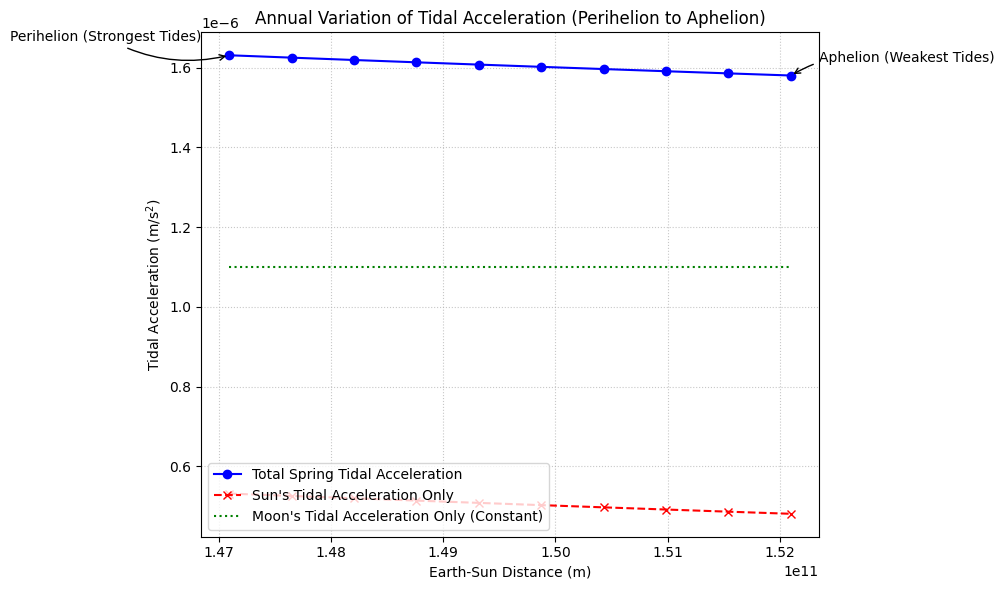

Distance: 3.63e+08 m | Moon Accel: 1.3030e-06
Distance: 3.68e+08 m | Moon Accel: 1.2538e-06
Distance: 3.73e+08 m | Moon Accel: 1.2071e-06
Distance: 3.77e+08 m | Moon Accel: 1.1626e-06
Distance: 3.82e+08 m | Moon Accel: 1.1204e-06
Distance: 3.87e+08 m | Moon Accel: 1.0801e-06
Distance: 3.91e+08 m | Moon Accel: 1.0417e-06
Distance: 3.96e+08 m | Moon Accel: 1.0052e-06
Distance: 4.01e+08 m | Moon Accel: 9.7032e-07
Distance: 4.06e+08 m | Moon Accel: 9.3705e-07


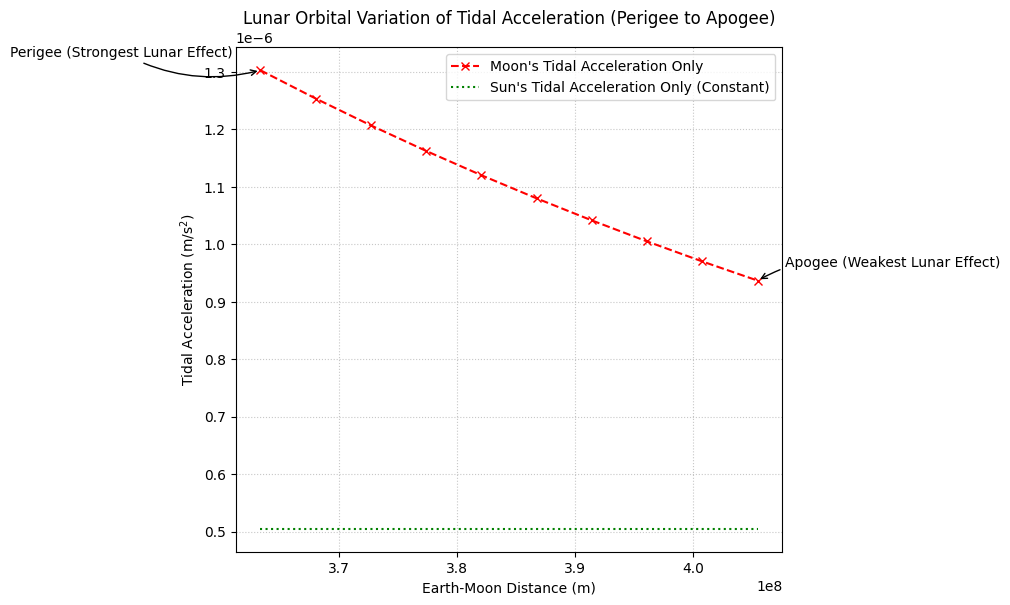

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.674e-11

class Planet:

    def __init__(self, name, mass_kg, radius_m):
        self.name = name
        self.mass = mass_kg
        self.radius = radius_m

    def calculate_gravitational_force(self, body_c, distance_m):
        force_g = G * self.mass * body_c.mass / (distance_m**2)
        return force_g

    def calculate_tidal_acceleration(self, body_c, distance_m):
        tidal_accel = 2 * G * body_c.mass * self.radius / (distance_m**3)
        return tidal_accel


earth_mass = 5.972e24
earth_radius = 6.371e6
earth = Planet("Earth", earth_mass, earth_radius)

moon_mass = 7.347e22
moon = Planet("Moon", moon_mass, 1.7374e6)

sun_mass = 1.989e30
sun = Planet("Sun", sun_mass, 6.963e8)


earth_moon_distance = 3.844e8 #In meters
avg_earth_sun_distance = 1.496e11

#Function for calculating tidal force in the motion of the earth in the course of a year
def annual_tidal_force_test(earth_obj, moon_obj, sun_obj):

    print("\n===============================================")
    print("### ANNUAL TIDAL FORCE VARIATION ANALYSIS ###")
    print("===============================================")

    #The max and min distance of the earth from the sun (Perihelion and Aphelion)
    perihelion_distance = 1.4709e11 # Closest (Jan 3rd)
    aphelion_distance = 1.5210e11 # Farthest (Jul 4th)

    #Had to use AI to help me figure out how to do this but this takes the apheloin and perihelion
    #to form a curve, which is then taken the natural log of to smooth out, creating a 10 equal points of the ellipses of revolution
    earth_sun_distances = np.linspace(perihelion_distance, aphelion_distance, 10)

    #Moon tidal acceleration
    accel_moon = earth_obj.calculate_tidal_acceleration(
        body_c=moon_obj,
        distance_m=earth_moon_distance
    )

    #Make a numpy array for the moon's acceleration
    moon_tidal_accels_const = np.full_like(earth_sun_distances, accel_moon)

    #Creates 2 lists to order data into later
    solar_tidal_accels = []
    combined_spring_accels = []

    #Loop for all 10 points (repeating the tidal acceleration function)
    for r_es in earth_sun_distances:
        #Calculates the acceleration at each distance "r_es"
        accel_sun = earth_obj.calculate_tidal_acceleration(
            body_c=sun_obj,
            distance_m=r_es
        )

        #sum up the forces (tidal accel)
        accel_spring = accel_moon + accel_sun

        solar_tidal_accels.append(accel_sun)
        combined_spring_accels.append(accel_spring)

        #Prettied up print statement
        solar_accel_readable = f"{accel_sun:.4e}"
        combined_accel_readable = f"{accel_spring:.4e}"
        print(f"Distance: {r_es:.2e} m | Sun Accel: {solar_accel_readable} | Total Spring Accel: {combined_accel_readable}")


    #Uses MatPlotlib to plot results
    plt.figure(figsize=(10, 6))

    #Sun+Moon forces on earth graphed in blue
    plt.plot(earth_sun_distances, combined_spring_accels, marker='o',
              linestyle='-', color='blue', label='Total Spring Tidal Acceleration')

    #Red plot for just the sun's forces
    plt.plot(earth_sun_distances, solar_tidal_accels, marker='x',
              linestyle='--', color='red', label='Sun\'s Tidal Acceleration Only')

    #Green for constant
    plt.plot(earth_sun_distances, moon_tidal_accels_const, linestyle=':', color='green',
             label='Moon\'s Tidal Acceleration Only (Constant)')

    #Sets labels for the graph
    plt.xlabel('Earth-Sun Distance (m)')
    plt.ylabel('Tidal Acceleration ($\mathrm{m/s^2}$)')
    plt.title('Annual Variation of Tidal Acceleration (Perihelion to Aphelion)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    #Max, min other details for the graph
    plt.annotate('Perihelion (Strongest Tides)',
                 (perihelion_distance, combined_spring_accels[0]),
                 textcoords="offset points", xytext=(-20,10), ha='right',
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

    plt.annotate('Aphelion (Weakest Tides)',
                 (aphelion_distance, combined_spring_accels[-1]),
                 textcoords="offset points", xytext=(20,10), ha='left',
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

#Run statement
annual_tidal_force_test(earth, moon, sun)


#plots varying force from sun + almost constant force from the moon
def plot_lunar_variation(earth_obj, moon_obj, sun_obj):

    #The max and min distance of the Earth from the Moon (Perigee and Apogee)
    perigee_distance = 3.633e8      # Closest (Perigee)
    apogee_distance = 4.055e8       # Farthest (Apogee)

    #10 equal points same method as before
    earth_moon_distances = np.linspace(perigee_distance, apogee_distance, 10)

    #Sun's tidal acceleration is constant over this short period
    accel_sun = earth_obj.calculate_tidal_acceleration(
        body_c=sun_obj,
        distance_m=avg_earth_sun_distance
    )
    sun_tidal_accels_const = np.full_like(earth_moon_distances, accel_sun)

    #Lists to store results
    lunar_tidal_accels = []

    #Loop for all 10 points
    for r_em in earth_moon_distances:
        #Calculates the acceleration at each Moon distance "r_em"
        accel_moon = earth_obj.calculate_tidal_acceleration(
            body_c=moon_obj,
            distance_m=r_em
        )
        lunar_tidal_accels.append(accel_moon)

        #Prettied up print statement
        lunar_accel_readable = f"{accel_moon:.4e}"
        print(f"Distance: {r_em:.2e} m | Moon Accel: {lunar_accel_readable}")


    #Uses MatPlotlib to plot results
    plt.figure(figsize=(10, 6))

    # Moon's varying forces plotted in red
    plt.plot(earth_moon_distances, lunar_tidal_accels, marker='x',
              linestyle='--', color='red', label='Moon\'s Tidal Acceleration Only')

    # Sun's constant force plotted in green (for visual comparison)
    plt.plot(earth_moon_distances, sun_tidal_accels_const, linestyle=':', color='green',
             label='Sun\'s Tidal Acceleration Only (Constant)')

    #Sets labels for the graph
    plt.xlabel('Earth-Moon Distance (m)')
    plt.ylabel(r'Tidal Acceleration ($\mathrm{m/s^2}$)')
    plt.title('Lunar Orbital Variation of Tidal Acceleration (Perigee to Apogee)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    #Max, min other details for the graph
    plt.annotate('Perigee (Strongest Lunar Effect)',
                 (perigee_distance, lunar_tidal_accels[0]),
                 textcoords="offset points", xytext=(-20,10), ha='right',
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

    plt.annotate('Apogee (Weakest Lunar Effect)',
                 (apogee_distance, lunar_tidal_accels[-1]),
                 textcoords="offset points", xytext=(20,10), ha='left',
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

#Run statement
plot_lunar_variation(earth, moon, sun)